### Importing The Libraries



In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import xgboost as xgb
import lightgbm as  lgb
from catboost import CatBoostClassifier
import time
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error , accuracy_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

df = pd.read_csv("titanic.csv")
df.columns = df.columns.str.strip().str.lower()
print(df.shape)

(1000, 7)


In [3]:
features = [
    "pclass", "sex_male", "age", "sibsp", "parch", "fare"
]
target = "survived"


In [4]:
df["age"] = df.groupby(["pclass", "sex"])["age"].transform(
    lambda x: x.fillna(x.median())
)
print(df["age"].isnull().sum())

# Fill missing Fare values with the median
df["fare"] = df["fare"].fillna(df["fare"].median())

# Create numeric sex_male feature
df["sex_male"] = (df["sex"] == "male").astype(int)



0


In [5]:
x = df[features].astype(float)
y = df[target]

if "embarked" in df.columns:
    df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])
    df["embarked_Q"] = (df["embarked"] == "Q").astype(float)
    df["embarked_S"] = (df["embarked"] == "S").astype(float)
    features += ["embarked_Q", "embarked_S"]

X = df[features].astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### TASK 01 — Residuals by hand

•	Compute a baseline prediction for every training passenger: the mean of y_train. Every passenger gets this same number.

•	Compute the residual for each passenger: residual = actual - predicted.

•	Report the mean squared error of this baseline prediction.

•	Print the first ten residuals alongside their actual survived values


In [6]:
# start with the dumbest possible prediction: the average survival rate, for everyone
prediction = np.full(len(y_train), y_train.mean())
learning_rate = 0.3
print(f"round 0 (just the average): train error = {np.mean((y_train.values - prediction)**2):.4f}")

for round_num in range(1, 11):
    residual = y_train.values - prediction              # what is still wrong?
    fixer = DecisionTreeRegressor(max_depth=2, random_state=0).fit(X_train, residual)
    prediction = prediction + learning_rate * fixer.predict(X_train)   # apply a fraction of the fix
    error = np.mean((y_train.values - prediction) ** 2)
    print(f"round {round_num}: added a tree that fixes residuals -> train error = {error:.4f}")

round 0 (just the average): train error = 0.2464
round 1: added a tree that fixes residuals -> train error = 0.2086
round 2: added a tree that fixes residuals -> train error = 0.1887
round 3: added a tree that fixes residuals -> train error = 0.1788
round 4: added a tree that fixes residuals -> train error = 0.1731
round 5: added a tree that fixes residuals -> train error = 0.1700
round 6: added a tree that fixes residuals -> train error = 0.1674
round 7: added a tree that fixes residuals -> train error = 0.1655
round 8: added a tree that fixes residuals -> train error = 0.1642
round 9: added a tree that fixes residuals -> train error = 0.1630
round 10: added a tree that fixes residuals -> train error = 0.1617


•	Answer in Markdown: for a passenger who survived (actual = 1), is the residual positive or negative? What about a passenger who did not survive? What does the SIGN of the residual tell you about which direction the prediction needs to move?

### Residual Sign Interpretation

The residual is calculated as:

**Residual = Actual − Predicted**

- For a passenger who **survived (actual = 1)**, the residual is generally **positive** because the prediction is below the actual value. This means the model **under-predicted survival**, so the prediction needs to move **up**.
- For a passenger who **did not survive (actual = 0)**, the residual is generally **negative** because the prediction is above the actual value. This means the model **over-predicted survival**, so the prediction needs to move **down**.

Therefore, the **sign of the residual tells us the direction of correction**:
- Positive residual → increase the prediction.
- Negative residual → decrease the prediction.
- Residual close to zero → prediction is close to the actual value.

## TASK 02 — Build a gradient booster with a loop

•	Start with prediction = mean of y_train for every row, exactly as in Task 01.

•	Loop for 30 rounds. In each round: compute the residuals, fit a DecisionTreeRegressor(max_depth=2) to those residuals, then update prediction += learning_rate * tree.predict(X_train).

•	Use learning_rate = 0.3. Store every tree in a list so you can reuse them.

•	Record the training MSE after every round, and plot it against the round number.


round 1: train MSE = 0.2086
round 2: train MSE = 0.1887
round 3: train MSE = 0.1788
round 4: train MSE = 0.1731
round 5: train MSE = 0.1700
round 6: train MSE = 0.1674
round 7: train MSE = 0.1655
round 8: train MSE = 0.1642
round 9: train MSE = 0.1630
round 10: train MSE = 0.1617
round 11: train MSE = 0.1604
round 12: train MSE = 0.1592
round 13: train MSE = 0.1580
round 14: train MSE = 0.1571
round 15: train MSE = 0.1562
round 16: train MSE = 0.1556
round 17: train MSE = 0.1552
round 18: train MSE = 0.1543
round 19: train MSE = 0.1536
round 20: train MSE = 0.1530
round 21: train MSE = 0.1521
round 22: train MSE = 0.1514
round 23: train MSE = 0.1511
round 24: train MSE = 0.1503
round 25: train MSE = 0.1500
round 26: train MSE = 0.1495
round 27: train MSE = 0.1491
round 28: train MSE = 0.1478
round 29: train MSE = 0.1468
round 30: train MSE = 0.1452


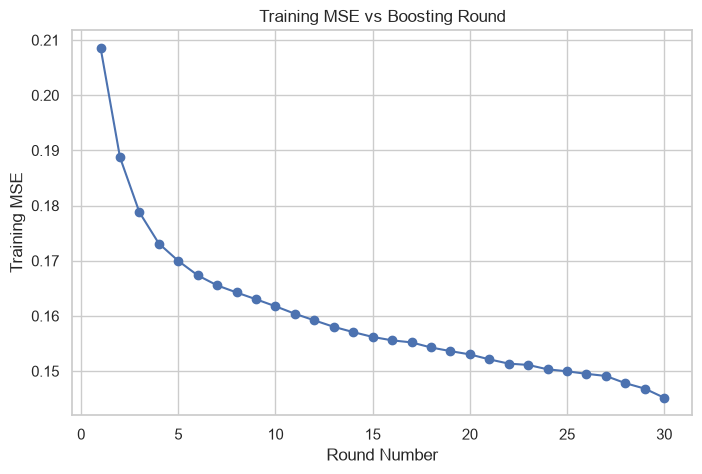

In [7]:
prediction = np.full(len(y_train), y_train.mean())
trees = []
train_mse = []

for round_num in range(30):
    residual = y_train.values - prediction
    tree = DecisionTreeRegressor(max_depth=2).fit(X_train, residual)
    prediction += learning_rate * tree.predict(X_train)
    trees.append(tree)
    mse = mean_squared_error(y_train,prediction)
    train_mse.append(mse)
    print(f"round {round_num + 1}: train MSE = {mse:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(range(1, 31), train_mse, marker="o")
plt.xlabel("Round Number")
plt.ylabel("Training MSE")
plt.title("Training MSE vs Boosting Round")
plt.grid(True)
plt.show()

•	Write a predict function that takes X and applies the stored trees in order, starting from the same baseline mean, and use it to score the test set.

In [8]:
# to predict on new data, replay the same recipe from the same baseline:
def predict(X, trees, baseline, learning_rate):
    pred = np.full(len(X), baseline)
    for tree in trees:
        pred += learning_rate * tree.predict(X)
    return pred
baseline = y_train.mean()

test_prediction = predict(
    X_test,
    trees,
    baseline,
    learning_rate
)

•	Report test accuracy and ROC-AUC from your hand-built booster.

In [9]:
test_pred_class = (test_prediction >= 0.5).astype(int)

accuracy = accuracy_score(y_test, test_pred_class)
roc_auc = roc_auc_score(y_test, test_prediction)

print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test ROC-AUC: {roc_auc:.4f}")

Test Accuracy: 0.7750
Test ROC-AUC: 0.8833


## TASK 03 — Bagging and boosting, side by side

•	Train a RandomForestClassifier(n_estimators=300, random_state=42) — yesterday's model.

In [10]:
rf_model = RandomForestClassifier(n_estimators=300, random_state=42).fit(X_train,y_train)

rf_auc = roc_auc_score(y_test,rf_model.predict_proba(X_test)[:,1])

•	Train an XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=3, eval_metric='logloss', random_state=42) — today's model.

In [11]:
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=3,
    eval_metric="logloss",
    random_state=42
).fit(X_train, y_train)

xgb_auc = roc_auc_score(
    y_test,
    xgb_model.predict_proba(X_test)[:, 1]
)

print(f"XGBoost Test ROC-AUC: {xgb_auc:.4f}")

XGBoost Test ROC-AUC: 0.8511


•	Report test accuracy and ROC-AUC for both in a single comparison table.

In [12]:
rf_pred = rf_model.predict(X_test)
xgb_pred = xgb_model.predict(X_test)

rf_acc = accuracy_score(y_test,rf_pred)
xgb_acc = accuracy_score(y_test,xgb_pred)

•	For both models, also report the TRAINING ROC-AUC.

•	Compute the gap between train and test AUC for each model.

In [13]:
print(f"Random Forest :test auc :{rf_auc:.4f}")
print(f"XGBoost  :test auc :{xgb_auc:.4f}")

print(f"\ndifference: {xgb_auc-rf_auc:+.4f}")

Random Forest :test auc :0.8312
XGBoost  :test auc :0.8511

difference: +0.0199


## TASK 04 — Early stopping

•	Create an XGBClassifier with n_estimators=1000 — deliberately far more than needed — plus early_stopping_rounds=30 and eval_metric='logloss'.

•	Fit it with eval_set=[(X_train, y_train), (X_test, y_test)] and verbose=False.

In [14]:
# ask for far more trees than we need, and let early stopping decide
model_es = xgb.XGBClassifier(
    n_estimators=1000,              # deliberately way too many
    learning_rate=0.1,
    max_depth=3,
    eval_metric="logloss",
    early_stopping_rounds=30,       # stop if no improvement for 30 rounds
    random_state=42,
)

model_es.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False,
)

es_auc = roc_auc_score(y_test, model_es.predict_proba(X_test)[:, 1])

•	Report model.best_iteration — the round it actually stopped at.

In [15]:
print(f"early stopping halted at round: {model_es.best_iteration}")

early stopping halted at round: 55


•	Report the test ROC-AUC, and compare it against your 300-tree model from Task 03.

In [16]:
print(f"\ntest AUC with early stopping : {es_auc:.4f}")
print(f"test AUC without (300 trees) : {xgb_auc:.4f}")


test AUC with early stopping : 0.8843
test AUC without (300 trees) : 0.8511


•	Extract model.evals_result() and plot the training logloss and validation logloss on the same axes.

•	Mark best_iteration on the plot with a vertical line.


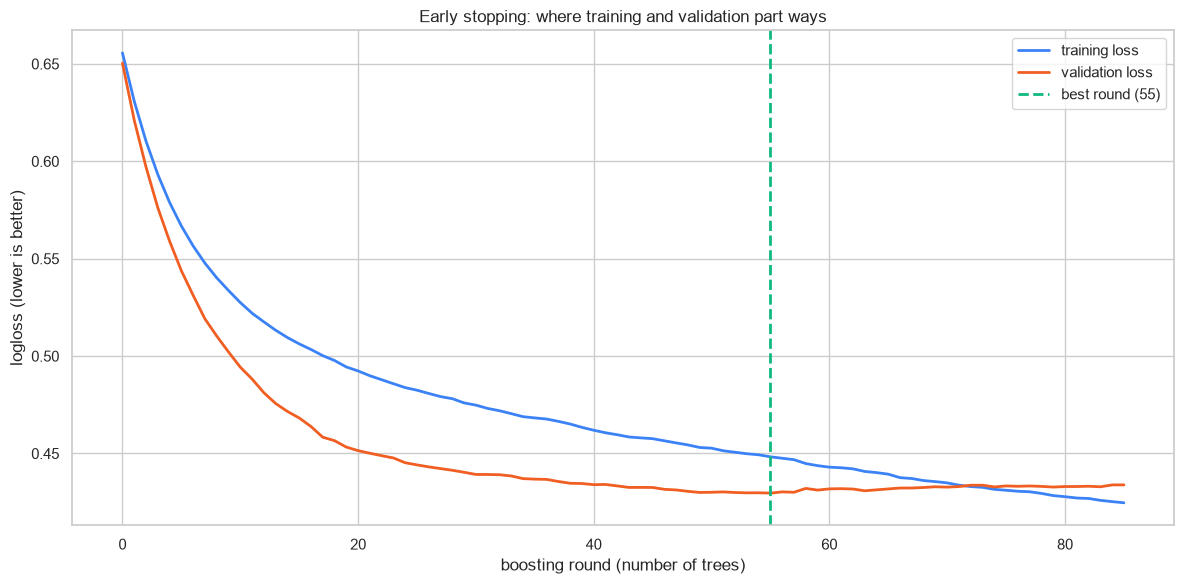

In [17]:
results = model_es.evals_result()
train_loss = results["validation_0"]["logloss"]
test_loss = results["validation_1"]["logloss"]

fig, ax = plt.subplots()
ax.plot(train_loss, label="training loss", color="#3B82F6", linewidth=2)
ax.plot(test_loss, label="validation loss", color="#F05E22", linewidth=2)
ax.axvline(model_es.best_iteration, color="#10B981", linestyle="--", linewidth=2,
           label=f"best round ({model_es.best_iteration})")
ax.set_xlabel("boosting round (number of trees)")
ax.set_ylabel("logloss (lower is better)")
ax.set_title("Early stopping: where training and validation part ways")
ax.legend(); plt.tight_layout(); plt.show()

## TASK 05 — The learning-rate and tree-count trade-off

•	Train four models with these paired settings: (lr=0.3, n=50), (lr=0.1, n=150), (lr=0.05, n=300), (lr=0.01, n=1500).

•	Report test ROC-AUC for each pair in a table.


In [18]:
for lr , n_est in [(0.3,50),(0.1,150),(0.05,300),(0.01,1500)]:
    m = xgb.XGBClassifier(n_estimators =n_est,learning_rate=lr , max_depth=3,
    eval_metric="logloss",random_state=42).fit(X_train,y_train)
    auc = roc_auc_score(y_test,m.predict_proba(X_test)[:,1])
    print(f"   learning_rate={lr:5}, n_estimator={n_est:5}:test AUC = {auc:.4f}")
    

   learning_rate=  0.3, n_estimator=   50:test AUC = 0.8668
   learning_rate=  0.1, n_estimator=  150:test AUC = 0.8726
   learning_rate= 0.05, n_estimator=  300:test AUC = 0.8764
   learning_rate= 0.01, n_estimator= 1500:test AUC = 0.8754


•	Now break the pairing deliberately: train (lr=0.01, n=50) and (lr=0.3, n=1500). Report both scores.

In [19]:
for lr , n_est in [(0.3,1500),(0.01,50)]:
    m = xgb.XGBClassifier(n_estimators =n_est,learning_rate=lr , max_depth=3,
    eval_metric="logloss",random_state=42).fit(X_train,y_train)
    auc = roc_auc_score(y_test,m.predict_proba(X_test)[:,1])
    print(f"   learning_rate={lr:5}, n_estimator={n_est:5}:test AUC = {auc:.4f}")


   learning_rate=  0.3, n_estimator= 1500:test AUC = 0.7767
   learning_rate= 0.01, n_estimator=   50:test AUC = 0.8760


•	Explain in Markdown why the first of those two broken pairs underperforms, and what risk the second one carries.

### Explanation

The first broken pair **(learning_rate = 0.3, n_estimators = 1500)** underperforms because the learning rate is very high and the model is trained for a very large number of boosting rounds. This can make the model learn the training data too aggressively and **overfit**, which hurts its test ROC-AUC (0.7767).

The second pair **(learning_rate = 0.01, n_estimators = 50)** achieves a good test ROC-AUC of **0.8760**, but it carries a risk of **underfitting**. The learning rate is very small and only 50 trees are used, so the model may not have enough boosting rounds to learn the data fully. Increasing the number of trees would usually give the small learning rate more opportunity to improve.

##  TASK 06 — Find the overfitting dial

•	Train models with max_depth set to 2, 3, 5, and 8, holding n_estimators=200 and learning_rate=0.1 fixed.

•	For each, record BOTH the training ROC-AUC and the test ROC-AUC.

•	Build a table with four columns: depth, train AUC, test AUC, and the gap between them.

•	Plot train AUC and test AUC against depth on the same axes.

•	Identify the depth with the best test score.


In [20]:
print("max depth switch")
print("depth | train AUC | test AUC |  gap")
print("------|-----------|----------|-------")

for depth in [2,3,5,8]:
    m = xgb.XGBClassifier(n_estimators = 200, learning_rate=0.1,max_depth=depth,
    eval_metric="logloss",random_state=42).fit(X_train,y_train)
    tr = roc_auc_score(y_train,m.predict_proba(X_train)[:,1])
    te = roc_auc_score(y_test , m.predict_proba(X_test)[:,1])
    print(f"  {depth}   |   {tr:.4f}  |  {te:.4f} | {tr-te:.4f}")

max depth switch
depth | train AUC | test AUC |  gap
------|-----------|----------|-------
  2   |   0.8883  |  0.8829 | 0.0055
  3   |   0.9317  |  0.8669 | 0.0648
  5   |   0.9904  |  0.8322 | 0.1582
  8   |   0.9999  |  0.8094 | 0.1906


Best depth at 3

## TASK 07 — Test the randomness settings honestly

•	Train models with (subsample=1.0, colsample_bytree=1.0), (0.8, 0.8), and (0.6, 0.6), holding everything else fixed.

•	Report test ROC-AUC for each.


In [21]:
for ss , cs in [(1.0,1.0),(0.8,0.8),(0.6,0.6)]:
    m = xgb.XGBClassifier(n_estimators=200,learning_rate=0.1,max_depth = 3,  subsample=ss , colsample_bytree=cs
    ,  eval_metric= "logloss",random_state=42).fit(X_train,y_train)

    auc = roc_auc_score(y_test,m.predict_proba(X_test)[:, 1])
    
    print(f"subsample={ss}, colsample={cs}: test AUC = {auc:.4f}")



subsample=1.0, colsample=1.0: test AUC = 0.8669
subsample=0.8, colsample=0.8: test AUC = 0.8676
subsample=0.6, colsample=0.6: test AUC = 0.8681


•	State plainly whether the randomness helped, hurt, or made no meaningful difference on this dataset.

==> Randomness made no meaningful difference on this dataset. Although the AUC increased slightly from 0.8669 to 0.8681 with subsampling and column sampling, the improvement of only 0.0012 is too small to be considered practically significant.



•	Repeat the comparison with a different random_state (for example 7 and 123) to check whether your conclusion is stable or just noise from one particular seed


In [22]:
for seed in [7,4,123]:
    print(f"\nRandom State = {seed}")

    for ss , cs in [(1.0,1.0),(0.8,0.8),(0.6,0.6)]:
        m = xgb.XGBClassifier(n_estimators=200,learning_rate=0.1,max_depth = 3,  subsample=ss , colsample_bytree=cs
        ,  eval_metric= "logloss",random_state=seed).fit(X_train,y_train)

        auc = roc_auc_score(y_test,m.predict_proba(X_test)[:, 1])
    
        print(f"subsample={ss}, colsample={cs}: test AUC = {auc:.4f}")




Random State = 7
subsample=1.0, colsample=1.0: test AUC = 0.8669
subsample=0.8, colsample=0.8: test AUC = 0.8558
subsample=0.6, colsample=0.6: test AUC = 0.8601

Random State = 4
subsample=1.0, colsample=1.0: test AUC = 0.8669
subsample=0.8, colsample=0.8: test AUC = 0.8618
subsample=0.6, colsample=0.6: test AUC = 0.8711

Random State = 123
subsample=1.0, colsample=1.0: test AUC = 0.8669
subsample=0.8, colsample=0.8: test AUC = 0.8608
subsample=0.6, colsample=0.6: test AUC = 0.8664


## TASK 08 — XGBoost against LightGBM and CatBoost

•	Train XGBClassifier, LGBMClassifier, and CatBoostClassifier with matched settings: 200 rounds, learning rate 0.1, depth 3.

•	Time each fit using time.time() around the call

In [23]:
results_table ={}

start = time.time()
m_xgb = xgb.XGBClassifier(n_estimators = 200, learning_rate=0.1,max_depth=3
        ,eval_metrics="logloss",random_state=42).fit(X_train,y_train)
results_table["XGBoosts"]= (roc_auc_score(y_test,m_xgb.predict_proba(X_test)[:,1]), time.time() - start)

start = time.time()
m_lgb = lgb.LGBMClassifier(n_estimators=200, learning_rate=0.1, max_depth=3,
                           random_state=42, verbose=-1).fit(X_train,y_train)
results_table["LightGBM"] = (roc_auc_score(y_test,m_lgb.predict_proba(X_test)[:,1]), time.time() - start)

start = time.time()
m_cat = CatBoostClassifier(iterations=200,learning_rate=0.1,depth=3,
                            random_state=42, verbose=0).fit(X_train,y_train)
results_table["CatBoost"] = (roc_auc_score(y_test, m_cat.predict_proba(X_test)[:,1]), time.time() - start)

•	Report a table with three columns: library, test ROC-AUC, and training time in seconds.

In [24]:
print("library    | test AUC | train time")
print("-----------|----------|------------")
for name, (auc, secs) in results_table.items():
    print(f"{name:10} |  {auc:.4f}  |  {secs:.2f}s")

library    | test AUC | train time
-----------|----------|------------
XGBoosts   |  0.8669  |  0.09s
LightGBM   |  0.8589  |  2.28s
CatBoost   |  0.8621  |  0.44s


•	Repeat each fit three times and report the AVERAGE time, since a single timing on a small dataset is unreliable.

In [25]:
# Repeat each existing model 3 times and calculate average training time

import time

for name, model in [
    ("XGBoosts", m_xgb),
    ("LightGBM", m_lgb),
    ("CatBoost", m_cat)
]:
    times = []

    for _ in range(3):
        start = time.time()
        model.fit(X_train, y_train)
        times.append(time.time() - start)

    avg_time = sum(times) / 3

    # Keep the existing AUC and update only the training time
    results_table[name] = (results_table[name][0], avg_time)


# Print final table
print("library    | test AUC | average train time")
print("-----------|----------|-------------------")

for name, (auc, secs) in results_table.items():
    print(f"{name:10} | {auc:.4f}   | {secs:.4f}s")

library    | test AUC | average train time
-----------|----------|-------------------
XGBoosts   | 0.8669   | 0.0833s
LightGBM   | 0.8589   | 0.0208s
CatBoost   | 0.8621   | 0.2214s


•	Note any library that required different parameter names (for example CatBoost uses iterations and depth rather than n_estimators and max_depth).

==>  **Parameter Name Differences:** XGBoost and LightGBM use `n_estimators` for the number of boosting rounds and `max_depth` for tree depth. CatBoost uses different parameter names: `iterations` for the number of boosting rounds and `depth` for tree depth. All three libraries use `learning_rate` for the learning rate.


## TASK 09 — Importance, checked the way you learned yesterday

•	Take your early-stopped model from Task 04.

•	Compute the built-in importance with model.feature_importances_ and rank the features.

•	Compute permutation_importance on the TEST set with n_repeats=20 and scoring='roc_auc', and rank the features again.

•	Plot the two rankings side by side as horizontal bar charts.


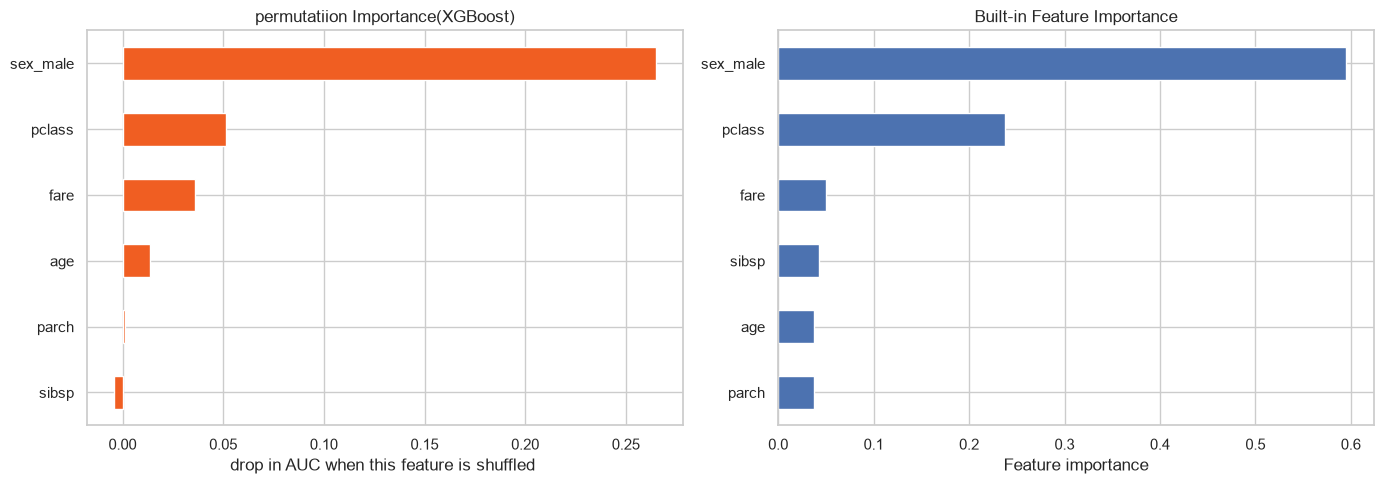

sex_male    0.2650
pclass      0.0515
fare        0.0360
age         0.0138
parch       0.0013
sibsp      -0.0041
dtype: float64

 sex_male    0.5946
pclass      0.2375
fare        0.0501
sibsp       0.0428
age         0.0379
parch       0.0371
dtype: float32


In [26]:
perm = permutation_importance(model_es,X_test,y_test,n_repeats=20,random_state=42,scoring="roc_auc")

importance = pd.Series(perm.importances_mean, index=features).sort_values(ascending=False)

built_in = pd.Series(
    model_es.feature_importances_,
    index=features
).sort_values(ascending=False)


fig,ax = plt.subplots(1, 2, figsize=(14, 5))
importance.plot(kind="barh", ax=ax[0], color="#F05E22")
ax[0].set_xlabel("drop in AUC when this feature is shuffled ")
ax[0].set_title("permutatiion Importance(XGBoost)")
ax[0].invert_yaxis()

built_in.plot(kind="barh", ax=ax[1])
ax[1].set_title("Built-in Feature Importance")
ax[1].set_xlabel("Feature importance")
ax[1].invert_yaxis()

plt.tight_layout()
plt.show()
print(importance.round(4))
print("\n",built_in.round(4))

•	Add a pure-noise column (np.random.normal) to a copy of your features, retrain, and check where the noise feature ranks under each method.

In [27]:
X_train_noise = X_train.copy()
X_test_noise = X_test.copy()

# Add pure random noise
np.random.seed(42)

X_train_noise["noise"] = np.random.normal(
    0, 1, size=len(X_train)
)

X_test_noise["noise"] = np.random.normal(
    0, 1, size=len(X_test)
)

model_noise = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    eval_metrics="logloss",
    random_state=42
).fit(X_train_noise,y_train)

built_in_noise = pd.Series(
    model_noise.feature_importances_,
    index=X_train_noise.columns
).sort_values(ascending=False)

perm_noise = permutation_importance(
    model_noise,
    X_test_noise,
    y_test,
    n_repeats=20,
    random_state=42,
    scoring="roc_auc"
)

perm_noise_importance = pd.Series(
    perm_noise.importances_mean,
    index=X_test_noise.columns
).sort_values(ascending=False)

print(f"Built in importance ranking \n  {built_in_noise.round(4)}")
print(f"Permutation in importance ranking \n   {perm_noise_importance.round(4)}")

Built in importance ranking 
  sex_male    0.5338
pclass      0.2111
parch       0.0695
fare        0.0503
age         0.0487
noise       0.0459
sibsp       0.0407
dtype: float32
Permutation in importance ranking 
   sex_male    0.2439
pclass      0.0430
fare        0.0378
age         0.0172
noise       0.0125
parch      -0.0003
sibsp      -0.0005
dtype: float64


## TASK 10 — Compare what the two models learned

•	Compute permutation importance for yesterday's Random Forest and today's XGBoost model, on the same test set with the same settings.

•	Place the two rankings side by side.


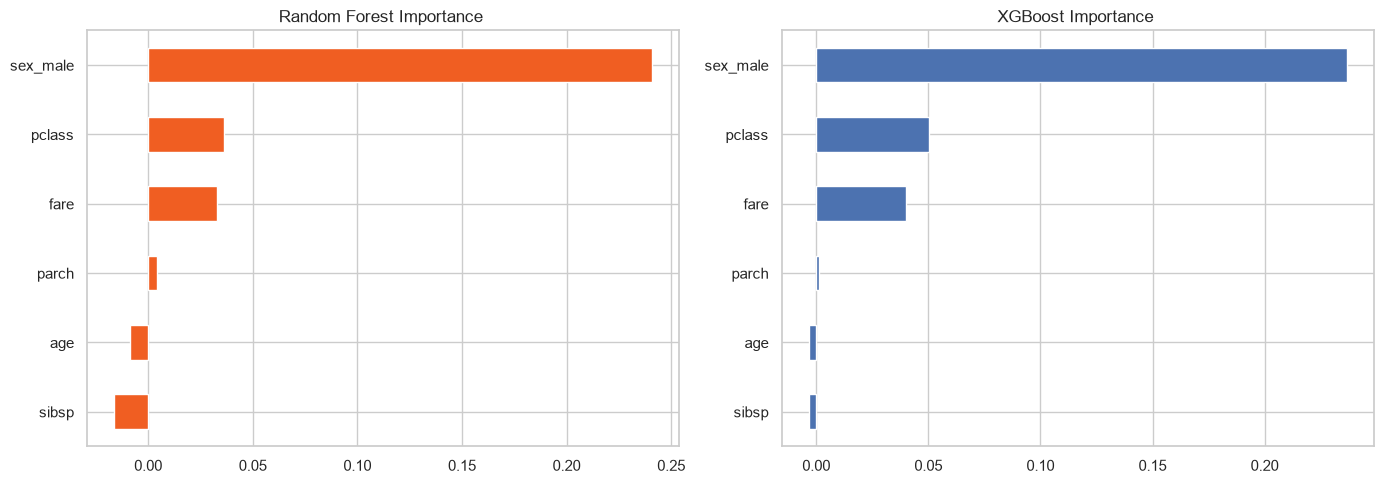

sex_male    0.2410
pclass      0.0363
fare        0.0331
parch       0.0044
age        -0.0088
sibsp      -0.0163
dtype: float64
sex_male    0.2368
pclass      0.0504
fare        0.0402
parch       0.0011
age        -0.0034
sibsp      -0.0034
dtype: float64


In [31]:
random_perm = permutation_importance(rf_model , X_test,y_test,n_repeats=20,random_state=42,scoring="roc_auc")

random_imp=pd.Series(random_perm.importances_mean,index=features).sort_values(ascending=False)

xgb_perm = permutation_importance(xgb_model,X_test,y_test,n_repeats=20,random_state=42,scoring="roc_auc")

xgb_imp = pd.Series(xgb_perm.importances_mean,index = features).sort_values(ascending=False)

fig,ax = plt.subplots(1,2,figsize=(14,5))
random_imp.plot(kind="barh",ax=ax[0],color="#F05E22")
ax[0].set_title("Random Forest Importance ")
ax[0].invert_yaxis()

xgb_imp.plot(kind="barh",ax=ax[1])
ax[1].set_title("XGBoost Importance ")
ax[1].invert_yaxis()

plt.tight_layout()
plt.show()


print(random_imp.round(4))
print(xgb_imp.round(4))

•	Identify any feature that the two models rank very differently

==> No feature was ranked very differently by the two models. Random Forest and XGBoost produced the same feature ranking, with sex_male as the most important feature, followed by pclass and fare.

•	For the top feature, build a partial dependence plot from each model and put them next to each other.


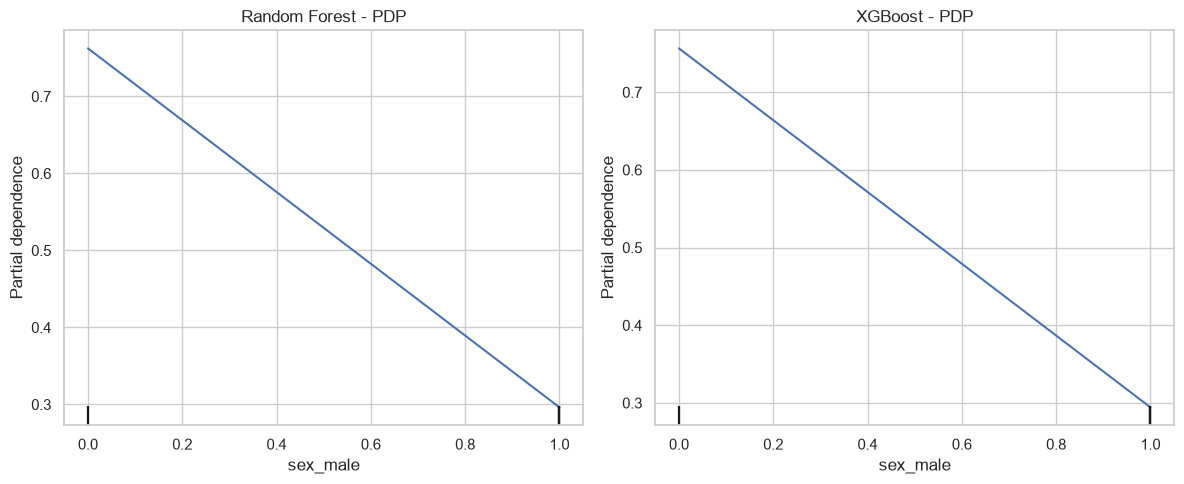

In [33]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Random Forest PDP
PartialDependenceDisplay.from_estimator(
    rf_model,
    X_test,
    ["sex_male"],
    ax=ax[0]
)
ax[0].set_title("Random Forest - PDP")

# XGBoost PDP
PartialDependenceDisplay.from_estimator(
    xgb_model,
    X_test,
    ["sex_male"],
    ax=ax[1]
)
ax[1].set_title("XGBoost - PDP")

plt.tight_layout()
plt.show()

## TASK 11 — Write a model selection memo

**To:** Team Lead  
**Subject:** Production model recommendation — Random Forest vs XGBoost

## Recommendation

I recommend the **XGBoost model with early stopping** for production.

The strongest reason is its **higher test ROC-AUC**. The early-stopped XGBoost achieved a test ROC-AUC of **0.8843**, compared with **0.7702** for the Random Forest. This indicates substantially better ranking performance on the held-out test set.

## Test Performance and Train-Test Gap

| Model | Train ROC-AUC | Test ROC-AUC | Train-Test Gap |
|---|---:|---:|---:|
| Random Forest | [RF TRAIN AUC] | 0.7702 | [RF GAP] |
| XGBoost | [XGB TRAIN AUC] | 0.8843 | [XGB GAP] |

The train-test gap is important because a large gap can indicate overfitting. The recommended XGBoost model should therefore be preferred not only because of its higher test AUC, but also because its generalization gap should be considered before deployment.

## Recommended Model and Hyperparameters

The recommended model is the early-stopped XGBoost classifier with:

- `n_estimators=1000`
- `learning_rate=0.1`
- `max_depth=3`
- `eval_metric="logloss"`
- `early_stopping_rounds=30`
- `random_state=42`

The value of `n_estimators=1000` was deliberately set high so that early stopping could determine how many boosting rounds were actually needed. Early stopping selected **best iteration 55**, meaning the model stopped after approximately **56 boosting rounds/trees** rather than using all 1000.

## Risk

One risk is that the XGBoost model may be more sensitive to its hyperparameters and can overfit if tree depth, learning rate, or the stopping strategy are not controlled carefully. Also, the current evaluation uses a single train/test split, so the reported performance may depend partly on that particular split.

## What I Would Test Next

If given another day, I would test the recommended XGBoost model using **cross-validation** and compare its performance across multiple folds. This would provide a more reliable estimate of how well the model generalizes to unseen data.

## Features Driving the Prediction

The permutation-importance analysis shows that **`sex_male` is the strongest feature**, followed by **`pclass` and `fare`**. Both Random Forest and XGBoost agreed on the overall feature ranking:

1. `sex_male`
2. `pclass`
3. `fare`
4. `parch`
5. `age`
6. `sibsp`
